In [1]:
import hashlib
from pathlib import Path

import arviz as az
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pymc_extras as pmx
import pytensor.tensor as pt
import scipy as sp
from astropy.table import Table
from astropy.visualization import quantity_support
from astroquery.gaia import Gaia

Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"
quantity_support()

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x7fd03fbbbb60>

In [2]:
ROOT = Path(".").resolve().parent
DATA_DIR = ROOT / "data"
output_dir = DATA_DIR / 'raw'
fields = [
    'source_id',
    'ra',
    'ra_error',
    'dec',
    'dec_error',
    'parallax',
    'parallax_error',
    'phot_g_n_obs',
    'phot_g_mean_flux',
    'phot_g_mean_flux_error',
    'phot_g_mean_mag',
    'phot_bp_n_obs',
    'phot_bp_mean_flux',
    'phot_bp_mean_flux_error',
    'phot_bp_mean_mag',
    'phot_rp_n_obs',
    'phot_rp_mean_flux',
    'phot_rp_mean_flux_error',
    'phot_rp_mean_mag',
]

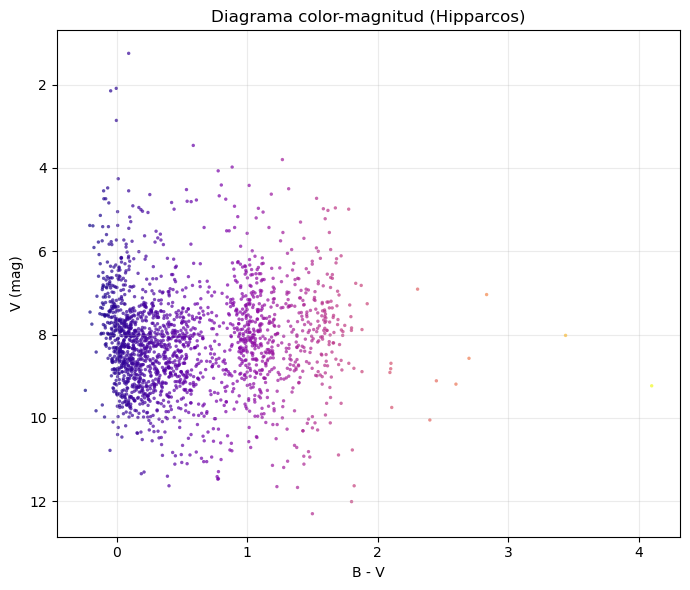

In [3]:
job = Gaia.launch_job("""
SELECT vmag, b_v
FROM public.hipparcos
WHERE vmag IS NOT NULL AND b_v IS NOT NULL
""")
r = job.get_results()

color = np.array(r["b_v"])
mag = np.array(r["vmag"])
mask = np.isfinite(color) & np.isfinite(mag)

plt.figure(figsize=(7, 6))
plt.scatter(
    color[mask],
    mag[mask],
    s=6,
    c=color[mask],
    cmap="plasma",
    alpha=0.7,
    edgecolors="none",
)
plt.gca().invert_yaxis()
plt.xlabel("B - V")
plt.ylabel("V (mag)")
plt.title("Diagrama color-magnitud (Hipparcos)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [4]:
def get_filename(query: str) -> str:
    _hash = hashlib.md5(query.encode()).hexdigest()
    return f"GaiaQuery_{_hash}.ecsv"

def query_data(query: str):
    filename = get_filename(query)

    if (output_dir / filename).exists():
        return Table.read(output_dir / filename)

    job = Gaia.launch_job_async(query)
    job.get_results().write(output_dir / filename)
    return job.get_results()

In [5]:
query = """
    SELECT
        source_id,
        phot_g_mean_mag + 5.0 * log10(parallax) - 10.0 as g_mag_abs,
        bp_rp
    FROM gaiadr3.gaia_source_lite
    WHERE
        parallax_over_error >= 5
        AND phot_bp_mean_flux_over_error > 0
        AND phot_rp_mean_flux_over_error > 0
        AND SQRT(POWER(2.5/log(10) / phot_bp_mean_flux_over_error, 2) + POWER(2.5/log(10) / phot_rp_mean_flux_over_error, 2)) <= 0.05
        AND random_index BETWEEN 0 AND 10000000
    """


In [6]:
import polars as pl

df = pl.read_csv(
    output_dir / get_filename(query),
    separator=" ",
    comment_prefix="#",
)
df

SOURCE_ID,g_mag_abs,bp_rp
i64,f64,f64
4251898360394382336,4.900883,1.3092537
4251856480275867264,2.494051,2.0110073
4251815248589977088,0.132275,3.0622778
4251899017637209344,3.047321,1.2327728
4251899086356781440,0.766124,2.742445
…,…,…
4251877302279619840,4.501376,1.0932732
4251897368369571456,3.811043,1.408351
4251835310270822400,3.89982,1.660677


In [7]:
query = """
SELECT
    gum.source_id,
    gum.ra,
    gum.dec,
    gum.barycentric_distance,
    gum.mag_g,
    gum.mag_bp,
    gum.mag_rp,
    gss.ra AS ra_sim,
    gss.ra_error,
    gss.dec AS dec_sim,
    gss.dec_error,
    gss.parallax,
    gss.parallax_error,
    gss.phot_g_mean_flux,
    gss.phot_g_mean_flux_error,
    gss.phot_g_mean_mag,
    gss.phot_bp_mean_flux,
    gss.phot_bp_mean_flux_error,
    gss.phot_bp_mean_mag,
    gss.phot_rp_mean_flux,
    gss.phot_rp_mean_flux_error,
    gss.phot_rp_mean_mag
FROM gaiadr3.gaia_universe_model gum 
    INNER JOIN gaiadr3.gaia_source_simulation gss ON (gum.source_id = gss.source_id)
"""

df = pl.read_csv(
    output_dir / get_filename(query),
    separator=" ",
    comment_prefix="#",
)
df

SOURCE_ID,ra,dec,barycentric_distance,mag_g,mag_bp,mag_rp,ra_sim,ra_error,dec_sim,dec_error,parallax,parallax_error,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_mag
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2234570208779960342,309.634677,44.53943,3906.326,19.83277,20.663525,18.896101,309.63467,0.4525417,44.539426,0.563914,-0.609326,0.8067439,204.79022,0.196589,19.830227,69.78428,0.671632,20.677406,195.33272,2.76211,18.902662
2234570208914178050,309.639202,44.536619,2812.0623,19.16983,19.989796,18.239313,309.639194,0.258548,44.53661,0.322162,0.233243,0.46089,376.4696,0.287562,19.169176,132.79422,0.760085,19.978851,358.88998,2.9939923,18.242197
2234570208914178053,309.630838,44.523173,1883.49,19.294579,20.211578,18.308914,309.63083,0.284687,44.523165,0.354651,0.247869,0.5073691,335.50922,0.2676443,19.294239,108.94412,0.6950137,20.19379,338.12003,3.1461005,18.306923
2234570208914178056,309.640406,44.534643,4419.081,18.511694,19.21783,17.65376,309.640399,0.1539058,44.534638,0.191767,0.192875,0.274345,689.8233,0.464483,18.511656,267.094,0.9017161,19.22014,615.3464,3.0260932,17.656801
2234570208914178057,309.642758,44.538252,1425.0234,17.1507,17.902935,16.264956,309.642745,0.061492,44.538229,0.076624,0.7806166,0.109619,2416.1802,1.4680774,17.150677,896.89166,1.083093,17.90495,2219.724,3.8041317,16.263853
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1769440527956049937,315.435405,38.048374,981.3088,18.758461,19.820705,17.692299,315.435423,0.1972791,38.048374,0.222504,1.0971702,0.318318,549.06244,0.380504,18.759445,153.02953,0.624161,19.824862,596.48517,3.5434403,17.690601
1769440527956049940,315.458289,38.05341,2676.1716,16.3285,16.797441,15.664374,315.458284,0.047097,38.053408,0.053122,0.4441494,0.075998,5153.9653,3.029534,16.328146,2484.956,1.885538,16.798504,3852.8635,3.83707,15.665141
1769440527956049945,315.439737,38.055404,1179.1047,18.190054,19.00826,17.267525,315.43973,0.127391,38.055372,0.143694,1.1547959,0.20557,927.70703,0.591713,18.189974,322.7755,0.8287466,19.01455,878.827,3.2856734,17.269842


In [8]:
df.columns

['SOURCE_ID',
 'ra',
 'dec',
 'barycentric_distance',
 'mag_g',
 'mag_bp',
 'mag_rp',
 'ra_sim',
 'ra_error',
 'dec_sim',
 'dec_error',
 'parallax',
 'parallax_error',
 'phot_g_mean_flux',
 'phot_g_mean_flux_error',
 'phot_g_mean_mag',
 'phot_bp_mean_flux',
 'phot_bp_mean_flux_error',
 'phot_bp_mean_mag',
 'phot_rp_mean_flux',
 'phot_rp_mean_flux_error',
 'phot_rp_mean_mag']

In [8]:
from astropy.io import ascii

polars_dtypes = {
    np.dtype('float32'): pl.Float32,
    np.dtype('float64'): pl.Float64,
    np.dtype('int64'): pl.Int64,
}

def query_data_with_header(query: str) -> pl.DataFrame:

    with open(output_dir / get_filename(query), 'r') as file:
        header_lines = []

        while True:
            tell = file.tell()
            line = file.readline()
            header_lines.append(line)
            if not line.startswith("#"):
                file.seek(tell)
                break

        header = ascii.read(header_lines, format="ecsv")

        df = pl.read_csv(
            file,
            separator=" ",
            comment_prefix="#",
            schema={
                column.name: polars_dtypes[column.dtype]
                for column in header.columns.values()
            }
        )

    return df, header

df, header = query_data_with_header(query)
df.drop_nans().sample(100)


SOURCE_ID,ra,dec,barycentric_distance,mag_g,mag_bp,mag_rp,ra_sim,ra_error,dec_sim,dec_error,parallax,parallax_error,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_mag
i64,f64,f64,f32,f32,f32,f32,f64,f32,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
2076320884762607659,211.177273,-57.746334,6149.416016,20.435556,21.158739,19.571186,211.177252,0.496763,-57.746337,0.826761,-0.241827,1.182777,117.292442,0.133403,20.435326,45.189472,0.590394,21.149206,105.919121,2.073538,19.567163
2062470006075031565,188.424969,-52.958524,2158.189697,18.148731,18.635355,17.477057,188.424943,0.083674,-52.958521,0.123371,0.425034,0.176497,963.063965,0.529953,18.149363,456.113007,0.981739,18.639118,725.8927,2.274715,17.477419
1948070850611642423,164.154298,-61.336539,2754.785645,20.312805,21.160252,19.370895,164.154273,0.968278,-61.33654,1.792939,2.786453,2.565005,131.223022,0.34288,20.313475,43.441208,1.281274,21.192045,119.440536,5.25134,19.43672
2061842674964496458,191.090918,-59.965622,5142.121582,20.490866,21.189007,19.644527,191.090905,0.51658,-59.965621,0.916682,0.9608,1.31142,111.377434,0.138772,20.491507,43.516415,0.626715,21.190166,98.191841,2.124402,19.649412
1730842674774147132,283.914137,-26.971859,6543.68457,18.561699,19.156544,17.793581,283.914142,0.255627,-26.971875,0.254753,-0.336959,0.364454,658.221497,0.585059,18.562571,284.702759,1.311617,19.150822,538.222778,3.61181,17.802195
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1991513830630359042,313.722253,-46.588219,4746.680664,18.903152,19.2155,18.401558,313.722265,0.239666,-46.588243,0.309744,0.530965,0.443124,481.091553,0.410484,18.902931,268.501709,1.474085,19.214432,308.91687,2.470222,18.404997
2016863848597815297,310.440847,-79.357271,1880.683838,20.346943,21.438618,19.256956,310.440865,0.186757,-79.35729,0.898154,1.149003,1.284913,6189.159668,3.871469,16.129421,3178.391846,2.376705,16.531281,4363.928711,4.169182,15.529906
2270520004170481721,263.584167,-21.402802,3158.865234,17.780758,18.451677,16.946985,263.584162,0.123052,-21.402811,0.117388,0.430516,0.167937,1352.414917,0.884265,17.780725,543.843262,1.075622,18.448116,1189.188965,3.412184,16.941473


In [22]:
sample = df.drop_nans().sample(100000)
color = sample["mag_bp"] - sample["mag_rp"]
mag = sample["mag_g"] - 5.0 * np.log10(sample["barycentric_distance"] * 1e3) + 5.0

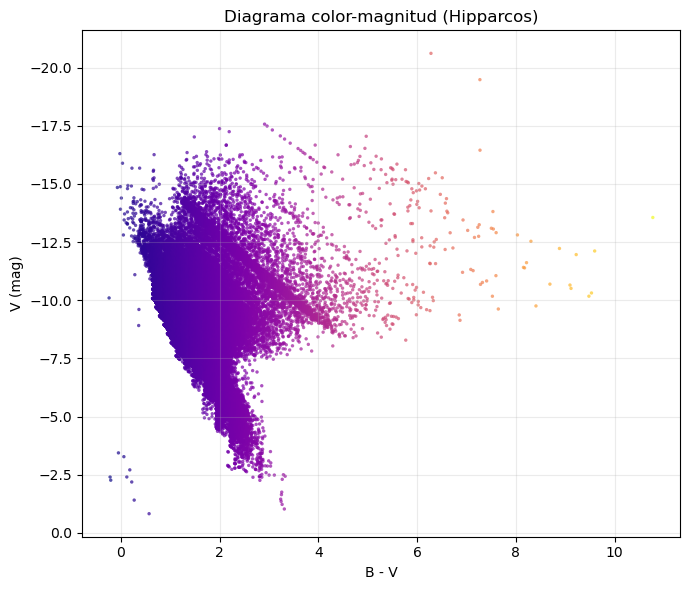

In [23]:
def plot_cmd(
    color,
    magnitude,
    *,
    ax=None,
    figsize=(7, 6),
    s=6,
    cmap="plasma",
    alpha=0.7,
    color_label="Color",
    mag_label="Magnitud",
    title="Diagrama color-magnitud (Hertzsprung-Russell)",
    grid_alpha=0.25,
):
    color = np.asarray(color)
    magnitude = np.asarray(magnitude)
    mask = np.isfinite(color) & np.isfinite(magnitude)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        color[mask],
        magnitude[mask],
        s=s,
        c=color[mask],
        cmap=cmap,
        alpha=alpha,
        edgecolors="none",
    )
    ax.invert_yaxis()
    ax.set_xlabel(color_label)
    ax.set_ylabel(mag_label)
    ax.set_title(title)
    ax.grid(alpha=grid_alpha)
    plt.tight_layout()

    return ax, scatter


plot_cmd(
    color,
    mag,
    color_label="B - V",
    mag_label="V (mag)",
    title="Diagrama color-magnitud (Hipparcos)",
)
plt.show()

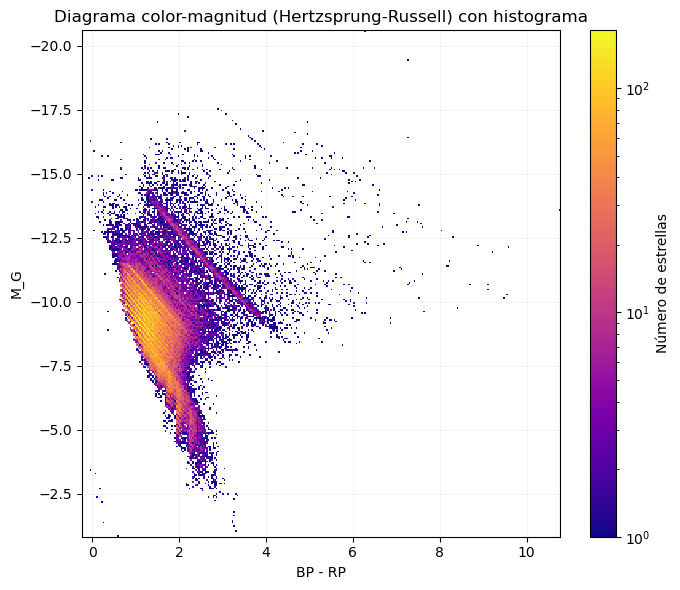

In [ ]:
def plot_cmd_hist(
    color,
    magnitude,
    *,
    ax=None,
    figsize=(7, 6),
    bins=300,
    cmap="plasma",
    log_scale=True,
    color_label="Color",
    mag_label="Magnitud",
    title="Diagrama color-magnitud (Hertzsprung-Russell)",
    grid_alpha=0.15,
    add_colorbar=True,
):
    color = np.asarray(color)
    magnitude = np.asarray(magnitude)
    mask = np.isfinite(color) & np.isfinite(magnitude)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    hist_kwargs = {
        "bins": bins,
        "cmap": cmap,
    }

    if log_scale:
        hist_kwargs["norm"] = mcolors.LogNorm()
        hist_kwargs["cmin"] = 1

    h = ax.hist2d(color[mask], magnitude[mask], **hist_kwargs)

    ax.invert_yaxis()
    ax.set_xlabel(color_label)
    ax.set_ylabel(mag_label)
    ax.set_title(title)
    ax.grid(alpha=grid_alpha)

    cbar = None
    if add_colorbar:
        cbar = plt.colorbar(h[3], ax=ax)
        cbar.set_label("Número de estrellas")

    plt.tight_layout()
    return ax, h, cbar


plot_cmd_hist(
    color,
    mag,
    color_label="BP - RP",
    mag_label="M_G",
    title="Diagrama color-magnitud (Hertzsprung-Russell) con histograma",
)
plt.show()